## Loading the dataset

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

In [3]:
def load_data():
    tarball_path = Path("Data/housing.tgz")  # Path where the .tgz file should be stored
    if not tarball_path.is_file():  # Check if the .tgz file does not already exist
        Path("Data").mkdir(parents=True, exist_ok=True)  # Create the Data directory if it doesn't exist
        url = "https://github.com/ageron/data/raw/main/housing.tgz"  # URL of the housing dataset
        urllib.request.urlretrieve(url, tarball_path)  # Download the .tgz file to the specified path
        with tarfile.open(tarball_path) as housing_tarball:  # Open the downloaded archive
            housing_tarball.extractall(path="Data")  # Extract all files into the Data directory

    return pd.read_csv(Path("Data//housing/housing.csv"))  # Load and return the dataset as a DataFrame

In [4]:
housing = load_data()

In [5]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


There are total 20639 interies and all have same number of enteries except for the total_bedrooms which has less number of enteries meaning that it has missing values

Since by using the head we have seen that ocean_proximity is a categorical type of coloumn we can see that how many values belong to which category by

In [7]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [8]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


this 25, 50 and 75 are percentile this mean that 25 percent of the housing median age is less then 18 and so on

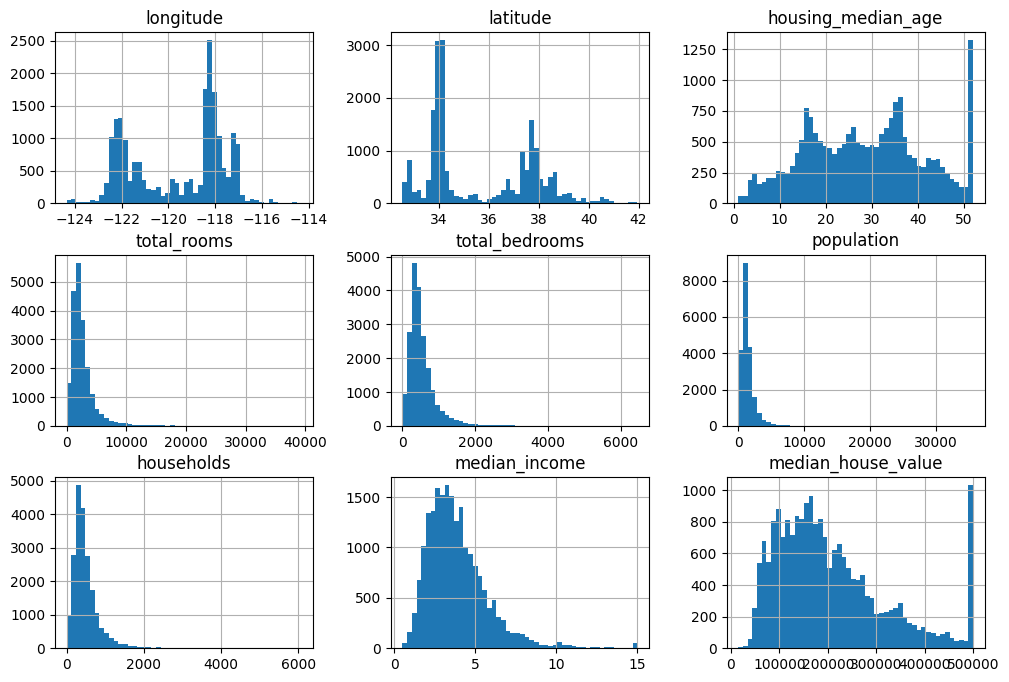

In [9]:
import matplotlib.pyplot as plt

housing.hist(bins=50 , figsize=(12 , 8))
plt.show()

Based on the plots there are several insights that can be understood
- The median income is not in plain dollars beacuse the max is 1500 instead its in the tens of thousands meaning 3 represent 30000. (this insight we got is from data description)
- The house value is also capped meaning at 1000 and it does not have any values greater then that so algorithm can predict that its the limit and price can not b greater then that
- The attributes have different scales
- Most of the features are skewed

#### Splitting the data

In [10]:
import numpy as np


In [11]:
def shuffle_and_split_data(data , test_ratio):
    """Shuffle a DataFrame and split it into training and test sets.

    Parameters:
        data (DataFrame): The DataFrame to split.
        test_ratio (float): The proportion of the data to include in the test set.

    Returns:
        tuple[DataFrame, DataFrame]: The training and test DataFrames.
    """
    np.random.seed(42) # to avoid function from seeing all the data we are setting the random seed to 42 so algorithm only see similar data.
    shuffled_indices = np.random.permutation(len(data))  # Shuffle the row indices.
    test_set_size = int(len(data) * test_ratio)  # Calculate the number of rows in the test set.
    test_indices = shuffled_indices[:test_set_size]  # Select the indices for the test set.
    train_indices = shuffled_indices[test_set_size:]  # Use the remaining indices for the training set.
    return data.iloc[train_indices], data.iloc[test_indices]  # Return the training and test DataFrames.

In [12]:
train_set_custom , test_set_custom = shuffle_and_split_data(housing , 0.2)

In [13]:
len(train_set_custom)

16512

In [14]:
len(test_set_custom)

4128

Instead of defining the custom functions to split the data the sciket learn provides the function for us to use and based on them we can split the data 

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
train_set , test_set = train_test_split(housing , test_size=0.2 , random_state=42) # this function works same as the train test custom function

In [17]:
len(train_set)

16512

In [18]:
len(test_set)

4128

For the above code we are just randomly cutting the data this is ok if we have large number of data but if we have small data and we want the data to be accurate representation of overall data we shoulld keep it in mind that the data in the accurate representation of the data

We want the  random data to be accurate representation of the overall data and it should preserve the median income in the both data we can do it so by

In [19]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)  # Create a new column by dividing the median income into five predefined income categories.

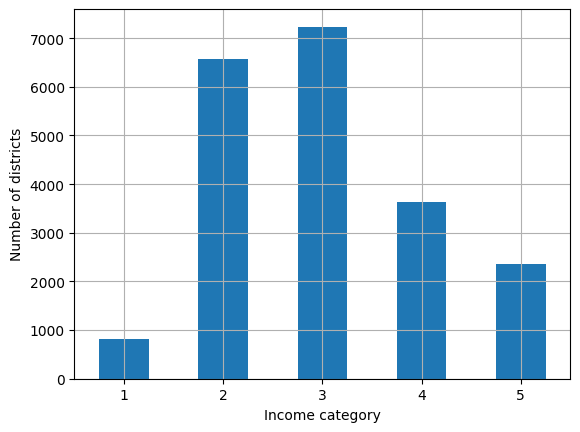

In [20]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot = 0 , grid = True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [21]:
strat_train_set, strat_test_set = train_test_split(
    housing,
    test_size=0.2,
    stratify=housing["income_cat"],  # Preserve the same income category distribution in both the training and test sets.
    random_state=42
)

stratify insures that if 20% of whole data belong to category 1 then 20% of training as well as test data belong to category 1 as well

In [22]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [23]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


Based on these figures we can see that if we have stratified result we can see that the error in it is quite less and its percentage is compareable to acutal percentage in the original resut

Since we wont use the income category coloum again we can drop it

In [24]:
for set_ in (strat_train_set , strat_test_set):
    set_.drop("income_cat" , axis = 1 , inplace = True)

In depth exploring of the data

In [25]:
housing = strat_train_set.copy()

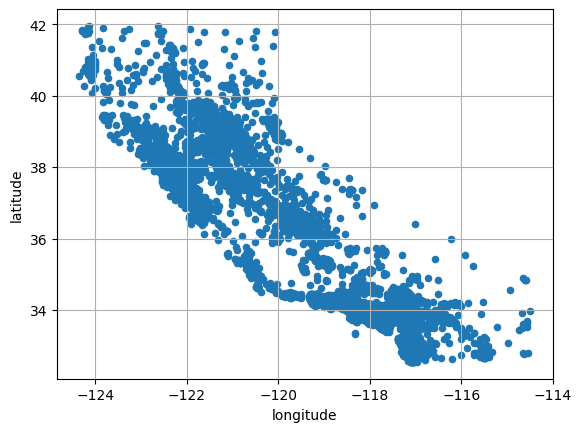

In [27]:
housing.plot(kind = "scatter" , x = "longitude" , y = "latitude" , grid = True)
plt.show()

This is okay but its hard to find any specific pattern we can change the alpha to see if we can find any specific pattern in the data or not

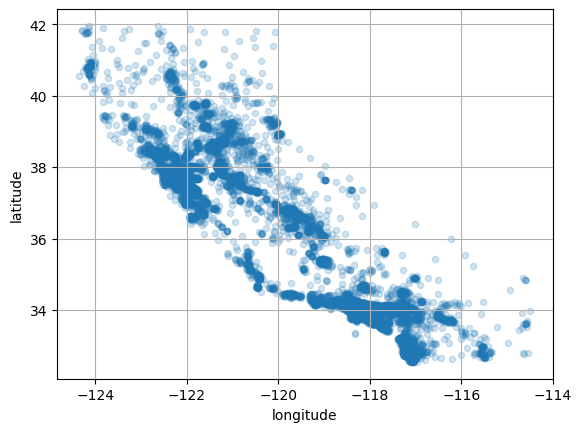

In [28]:
housing.plot(kind = "scatter" , x = "longitude" , y = "latitude" , grid = True , alpha = 0.2)
plt.show()

Now we can see based on this where the desnly packed population is based on the longitutde and latitude

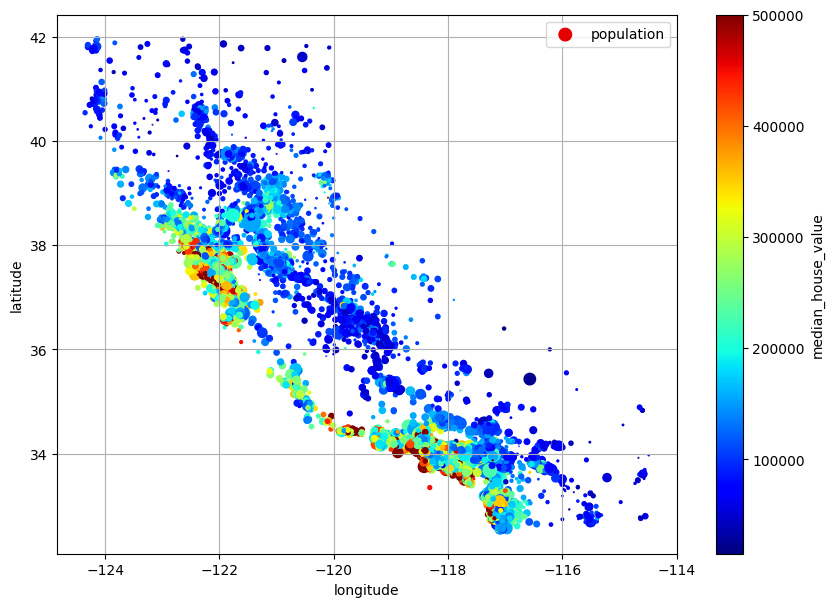

In [ ]:
housing.plot(
    kind="scatter",                  # Create a scatter plot (each row is represented as a point)

    x="longitude",                   # Use the longitude column for the x-axis
    y="latitude",                    # Use the latitude column for the y-axis

    grid=True,                       # Display grid lines to make the plot easier to read

    s=housing["population"] / 100,   # Size of each point based on population
                                    # Divide by 100 so the circles are not too large

    label="population",              # Label for the point sizes (used in the legend)

    c="median_house_value",          # Color each point based on the median house value

    cmap="jet",                      # Color map used to represent house values
                                    # Lower values get cooler colors, higher values warmer colors

    colorbar=True,                   # Show a color bar explaining what each color represents

    legend=True,                     # Display the legend (shows the population label)

    sharex=False,                    # Do not share the x-axis with any previous plot
                                    # Prevents axis limits from being inherited

    figsize=(10, 7)                  # Set the figure size to 10 inches wide and 7 inches tall
)

plt.show()                           # Display the completed plot

This plot is basically showing the location, size of the population represented by the size of the dot and the price what is the price based on the color

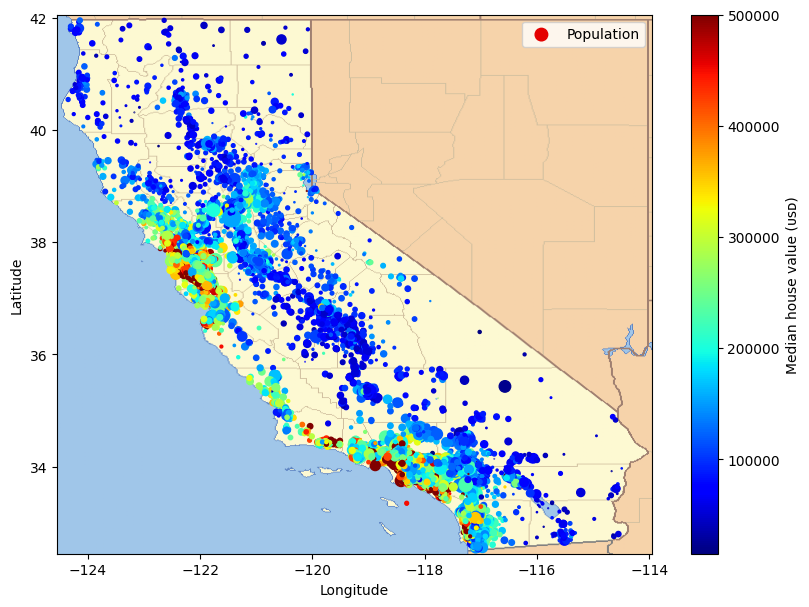

In [37]:
# extra code – this cell generates the first figure in the chapter

# Download the California image
filename = "california.png"
IMAGES_PATH = Path("F://Hands_on_ml//Chapter_2//Data")
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH /  filename)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

california_img = plt.imread(IMAGES_PATH /  filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

plt.show()

Based on this Image we can see that the houses close to the bay area are the most expensive one

### Correlations

Since the data is small we can see the collaration between the data this can be done by computing the standard correlation also called pearsons r

In [38]:
corr_matrix = housing.corr(numeric_only=True)

In [39]:
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Based on this we can see the relation of different coloumns with the values how different coloumns are related to the house value

The value of the cofficent range from -1 to 1.
- If the value is close to 1 it mean there is positive correlation like the median income it mean that the house value increase with the median income.
- if the value is close to -1 it mean there is negative correlation like the latitude and the house value we see that the price will go down when we go north.
- if the value is close to 0 it mean there is no linear correlation